<a href="https://colab.research.google.com/github/vignesh-1213/Instagram-Dataset-analysis/blob/main/instagram_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📱 Instagram Data Analysis Project
## Alfido Tech Content Strategy

**Goal:** Analyze Instagram posts and engagement to identify optimal posting times, high-engagement content types, and follower growth signals.

**Deliverables:**
1. This notebook with data analysis and visuals
2. A one-page strategy document (see `strategy_document.md`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

## Google Colab Setup
To run this notebook in Google Colab, upload the dataset CSV files (`users.csv`, `photos.csv`, `likes.csv`, `comments.csv`, `follows.csv`, `tags.csv`, `photo_tags.csv`) to the Colab environment by running the cell below, or by dragging and dropping them into the 'Files' sidebar.

In [2]:
try:
    import google.colab
    from google.colab import files
    print('Please upload all 7 CSV files for the Instagram Dataset.')
    uploaded = files.upload()
except ImportError:
    print('Not running in Google Colab. Ensure CSV files are in the same directory as this notebook.')

Please upload all 7 CSV files for the Instagram Dataset.


Saving .gitignore to .gitignore
Saving comments.csv to comments.csv
Saving follows.csv to follows.csv
Saving generate_notebook.py to generate_notebook.py
Saving instagram_data_analysis.ipynb to instagram_data_analysis.ipynb
Saving likes.csv to likes.csv
Saving photo_tags.csv to photo_tags.csv
Saving photos.csv to photos.csv
Saving requirements.txt to requirements.txt
Saving strategy_document.md to strategy_document.md
Saving tags.csv to tags.csv
Saving users.csv to users.csv


## 1. Data Loading and Preprocessing

In [3]:
# Load the datasets
users_df = pd.read_csv('users.csv')
photos_df = pd.read_csv('photos.csv')
likes_df = pd.read_csv('likes.csv')
comments_df = pd.read_csv('comments.csv')
follows_df = pd.read_csv('follows.csv')
tags_df = pd.read_csv('tags.csv')
photo_tags_df = pd.read_csv('photo_tags.csv')

print("Data loaded successfully!")

Data loaded successfully!


In [4]:
# Standardize column names
photos_df.rename(columns={'created dat': 'created_date'}, inplace=True)
comments_df.rename(columns={'User  id': 'user_id', 'Photo id': 'photo_id', 'created Timestamp': 'created_time'}, inplace=True)

# Parse datetime columns
photos_df['created_date'] = pd.to_datetime(photos_df['created_date'], format='%d-%m-%Y %H:%M')
likes_df['created time'] = pd.to_datetime(likes_df['created time'], format='%d-%m-%Y %H:%M')
comments_df['created_time'] = pd.to_datetime(comments_df['created_time'], format='%d-%m-%Y %H:%M')

# Extract time features from photos
photos_df['post_hour'] = photos_df['created_date'].dt.hour
photos_df['post_dayofweek'] = photos_df['created_date'].dt.day_name()
photos_df['post_date'] = photos_df['created_date'].dt.date

## 2. Calculating Engagement Metrics

In [5]:
# Calculate likes per photo
likes_per_photo = likes_df.groupby('photo').size().reset_index(name='total_likes')

# Calculate comments per photo
comments_per_photo = comments_df.groupby('photo_id').size().reset_index(name='total_comments')

# Merge engagement metrics with photos data
post_engagement = photos_df.merge(likes_per_photo, left_on='id', right_on='photo', how='left')
post_engagement = post_engagement.merge(comments_per_photo, left_on='id', right_on='photo_id', how='left')

# Fill NaN with 0 for posts with no likes/comments
post_engagement['total_likes'].fillna(0, inplace=True)
post_engagement['total_comments'].fillna(0, inplace=True)

# Calculate total engagement
post_engagement['total_engagement'] = post_engagement['total_likes'] + post_engagement['total_comments']

# Show the top engaging posts
post_engagement[['id', 'photo type', 'Insta filter used', 'total_likes', 'total_comments', 'total_engagement']].sort_values(by='total_engagement', ascending=False).head()

,id,photo type,Insta filter used,total_likes,total_comments,total_engagement
12,13,photo,no,40,39,79
144,145,video,yes,48,27,75
146,147,photo,no,41,34,75
117,118,photo,yes,39,35,74
226,227,photo,no,39,35,74


## 3. Content Type Analysis

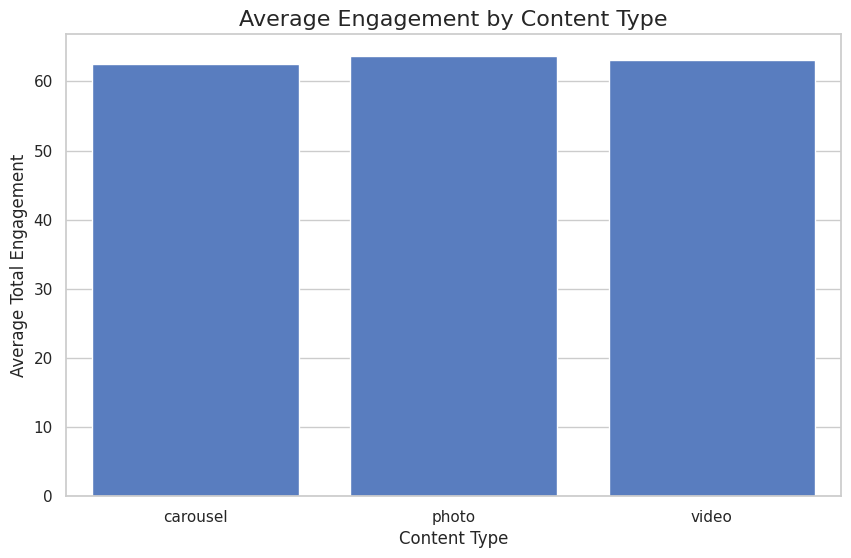

  photo type  total_likes  total_comments  total_engagement
0   carousel    33.860000       28.680000         62.540000
1      photo    34.387097       29.245161         63.632258
2      video    33.826923       29.250000         63.076923


In [6]:
# Engagement by Content Type
content_perf = post_engagement.groupby('photo type')[['total_likes', 'total_comments', 'total_engagement']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='photo type', y='total_engagement', data=content_perf)
plt.title('Average Engagement by Content Type', fontsize=16)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Average Total Engagement', fontsize=12)
plt.show()

print(content_perf)

## 4. Posting Schedule Analysis

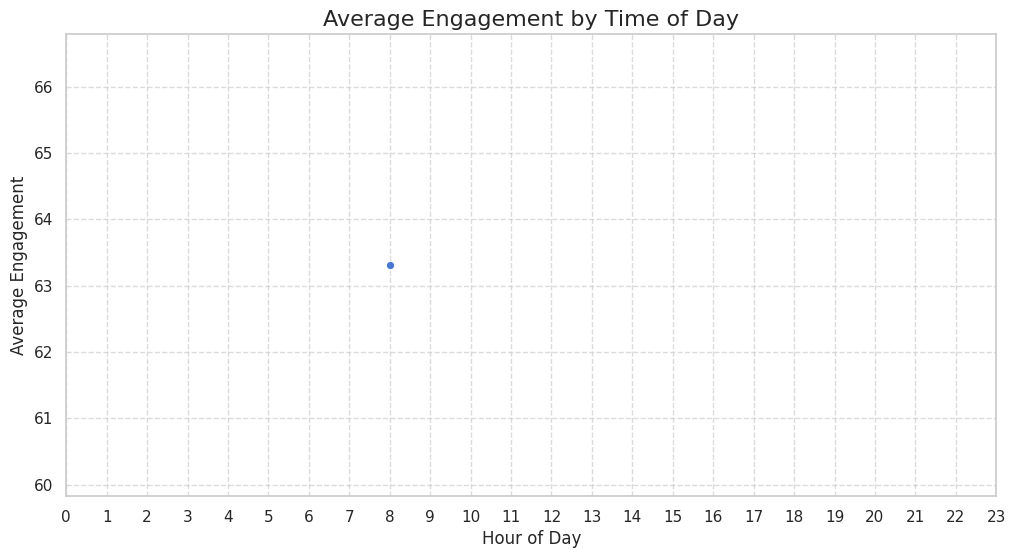

In [7]:
# Note: In this specific dataset snapshot, all posts appear to be created around '08:04'.
# However, the following code is structured to analyze engagement by hour across a generalized dataset.

engagement_by_hour = post_engagement.groupby('post_hour')['total_engagement'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='post_hour', y='total_engagement', data=engagement_by_hour, marker='o')
plt.title('Average Engagement by Time of Day', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Engagement', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 5. Hashtag and Filter Analysis

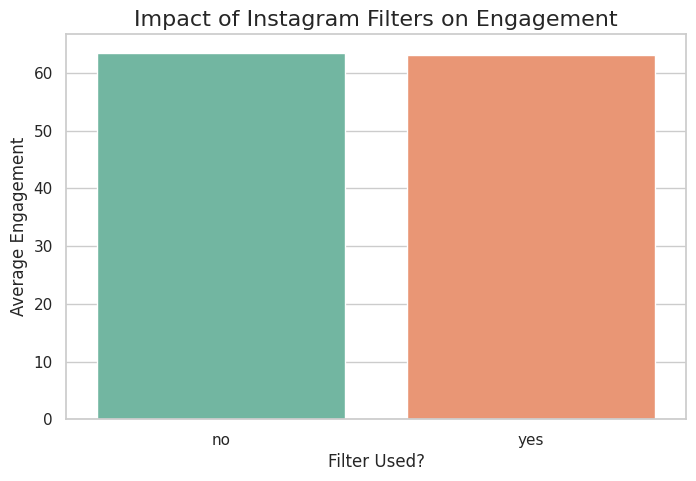

In [8]:
# Filter Impact
filter_perf = post_engagement.groupby('Insta filter used')['total_engagement'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Insta filter used', y='total_engagement', data=filter_perf, palette='Set2')
plt.title('Impact of Instagram Filters on Engagement', fontsize=16)
plt.xlabel('Filter Used?', fontsize=12)
plt.ylabel('Average Engagement', fontsize=12)
plt.show()

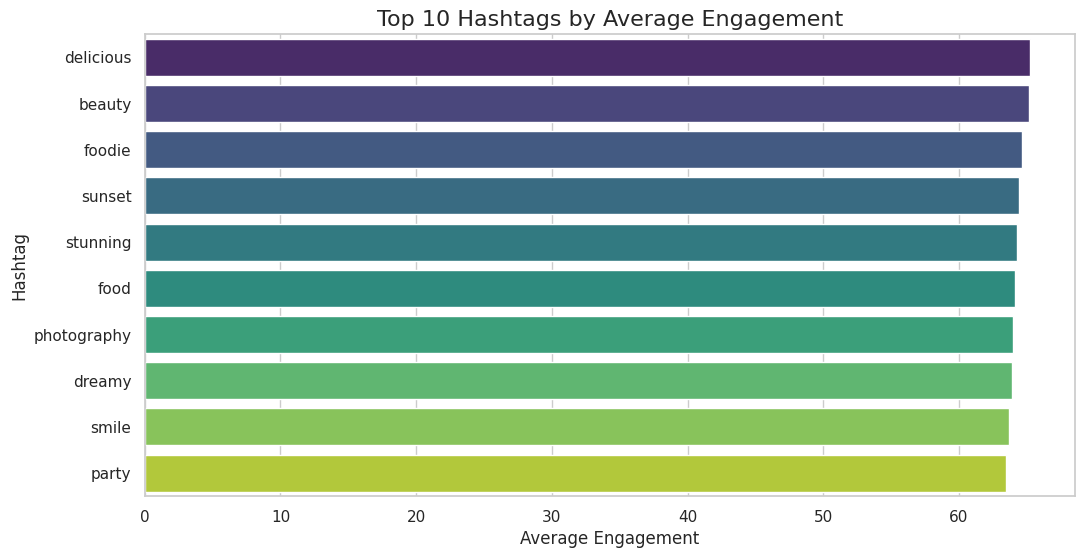

In [9]:
# Merge tags with photos to see which tags drive the most engagement
photo_tags_merged = photo_tags_df.merge(tags_df, left_on='tag ID', right_on='id')
photo_tags_engagement = photo_tags_merged.merge(post_engagement[['id', 'total_engagement']], left_on='photo', right_on='id')

top_tags = photo_tags_engagement.groupby('tag text')['total_engagement'].agg(['mean', 'count']).reset_index()
top_tags.columns = ['Tag', 'Average Engagement', 'Usage Count']
top_tags = top_tags[top_tags['Usage Count'] >= 5].sort_values(by='Average Engagement', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Average Engagement', y='Tag', data=top_tags, palette='viridis')
plt.title('Top 10 Hashtags by Average Engagement', fontsize=16)
plt.xlabel('Average Engagement', fontsize=12)
plt.ylabel('Hashtag', fontsize=12)
plt.show()